In [2]:
import sys
from pathlib import Path

sys.path.append(str(Path("..").resolve()))

from src.data.dataloader import MIDASDataset
from torchvision import transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [3]:
transform = transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor()])

dataset = MIDASDataset(data_dir="../sample_data/images", csv_file="../sample_data/midas_sample.csv", transform=transform)
loader = DataLoader(dataset, batch_size=1, shuffle=True)

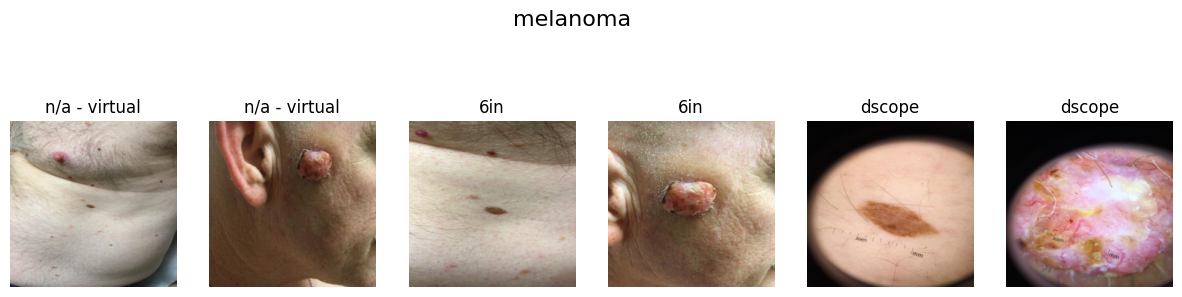

In [19]:
images, image_types, labels = next(iter(loader))
patient_images = images[0] 
patient_img_types = image_types[0]

type_map = {0: "dscope", 1: "6in", 2: "1ft", 2: "n/a - virtual"}
class_map = {"('no',)": "no melanoma", "('yes',)": "melanoma"}

plt.figure(figsize=(15, 4))
for i in range(patient_images.shape[0]):
    image = patient_images[i].permute(1, 2, 0)
    plt.subplot(1, patient_images.shape[0], i + 1)
    plt.imshow(image)
    plt.axis("off")
    plt.title(type_map[int(patient_img_types[i])])
plt.suptitle(f"{class_map[str(labels)]}", fontsize=16)
plt.show()